# CS4403 Data Mining Project — Darknet Traffic Mining & Classification (CIC-Darknet2020)

## Project overview
This project uses **network flow data** to explore whether different types of internet traffic (especially **privacy-enhancing traffic like Tor and VPN**) show measurable statistical patterns.  
Each row in the dataset represents a **single network flow** (a summarized communication session), and each column contains a numeric feature describing that flow (e.g., packet counts, packet length statistics, timing/inter-arrival statistics, and active/idle behavior).

## Dataset
- **Name / Source:** CIC-Darknet2020 (Canadian Institute for Cybersecurity, University of New Brunswick)
- **Local file used in this notebook:** `Darknet.CSV`
- **Scale:** ~140k+ flow records and ~80+ features (exact counts printed after loading)
- **Labels (targets):**
  - `Label` → **Traffic type** (e.g., Tor / VPN / NonVPN / Non-Tor depending on the dataset version)
  - `Label.1` → **Application category** (e.g., Browsing, Chat, Audio-Streaming, File-Transfer, etc.)

## Project goals
### Goal 1 — Supervised learning (classification)
Build and compare machine learning models that can predict the **traffic type** (`Label`) from flow features.  
We evaluate models using metrics such as **accuracy, precision, recall, F1-score**, and a **confusion matrix** to understand where the model performs well or struggles.

### Goal 2 — Unsupervised learning (pattern discovery)
Explore whether flows naturally form groups using clustering (e.g., K-means / DBSCAN).  
This helps answer: *Do different traffic types form distinct clusters based only on their behavior features?*

### Goal 3 — Explainability and reliability
Because very high accuracy can sometimes happen due to shortcuts (e.g., hidden leakage, duplicates, or latent factors), we include checks to:
- test **overfitting risk** (train vs test gap, cross-validation)
- test for **data leakage / shortcuts** (dropping identifier-like columns)
- investigate **latent factors** (relationships between `Label` and `Label.1`, duplicates, and group-based splits if possible)
- explain what the model is using via **feature importance**

## What this notebook contains
1. Load dataset and summarize size/labels (required for reports)
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Baseline supervised models + evaluation
5. Clustering exploration (optional section)
6. Robustness checks (overfitting / leakage / latent factors)
7. Feature importance + interpretation

In [2]:
import time
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', 100)
%matplotlib inline

In [3]:
pd.reset_option('all')

/tmp/ipykernel_175/2786130087.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
/tmp/ipykernel_175/2786130087.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nInfo():")
df.info()

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())


Dataset Shape:
(158616, 85)

Column Names:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag 

,0
Flow ID,object
Src IP,object
Src Port,int64
Dst IP,object
Dst Port,int64
...,...
Idle Std,float64
Idle Max,float64
Idle Min,float64
Label,object



Missing Values:


,0
Flow ID,0
Src IP,0
Src Port,0
Dst IP,0
Dst Port,0
...,...
Idle Std,0
Idle Max,0
Idle Min,0
Label,0



Duplicate Rows:
39004

Statistical Summary:


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,158616.000000,158616.000000,158616.000000,1.586160e+05,158616.000000,158616.000000,1.586160e+05,1.586160e+05,158616.000000,158616.000000,...,158616.000000,158616.000000,158616.0,158616.0,158616.0,158616.0,1.586160e+05,1.586160e+05,1.586160e+05,1.586160e+05
mean,38355.190599,17444.423684,10.220671,2.064569e+07,139.584058,142.036547,1.006577e+05,1.194523e+05,208.381134,15.142136,...,87.662146,15.885863,0.0,0.0,0.0,0.0,7.134231e+14,5.873675e+13,7.435619e+14,6.023175e+14
std,19256.809575,22113.288014,5.398461,3.799717e+07,2247.873161,3230.451392,3.071446e+06,4.313782e+06,625.564393,30.300339,...,1496.097737,6.955550,0.0,0.0,0.0,0.0,7.052456e+14,2.006960e+14,7.248794e+14,7.145478e+14
min,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,32916.000000,80.000000,6.000000,4.944250e+03,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,8.000000,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,43533.000000,4070.000000,6.000000,4.169220e+05,2.000000,1.000000,4.400000e+01,0.000000e+00,34.000000,0.000000,...,1.000000,20.000000,0.0,0.0,0.0,0.0,7.281651e+14,0.000000e+00,1.427909e+15,5.664990e+06
75%,53260.000000,39817.250000,17.000000,1.171051e+07,4.000000,3.000000,2.380000e+02,2.160000e+02,107.000000,31.000000,...,2.000000,20.000000,0.0,0.0,0.0,0.0,1.456253e+15,1.210090e+07,1.456322e+15,1.456253e+15
max,65534.000000,65535.000000,17.000000,1.200000e+08,238161.000000,470862.000000,7.693074e+08,6.704287e+08,64240.000000,1350.000000,...,113325.000000,44.000000,0.0,0.0,0.0,0.0,1.456417e+15,1.029836e+15,1.456417e+15,1.456417e+15


In [7]:
import pandas as pd

df = pd.read_csv('Darknet (1).CSV')

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

/tmp/ipykernel_175/3712993090.py:3: DtypeWarning: Columns (40,41,43,46,123,124) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Darknet (1).CSV')


Dataset Shape: (141531, 125)

Columns:
Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       ...
       'Unnamed: 115', 'Unnamed: 116', 'Unnamed: 117', 'Unnamed: 118',
       'Unnamed: 119', 'Unnamed: 120', 'Unnamed: 121', 'Unnamed: 122',
       'Unnamed: 123', 'Unnamed: 124'],
      dtype='object', length=125)

Data Types:
Flow ID          object
Src IP           object
Src Port          int64
Dst IP           object
Dst Port          int64
                 ...   
Unnamed: 120    float64
Unnamed: 121    float64
Unnamed: 122    float64
Unnamed: 123     object
Unnamed: 124     object
Length: 125, dtype: object

Missing Values:
Flow ID              0
Src IP               0
Src Port             0
Dst IP               0
Dst Port             0
                 ...  
Unnamed: 120    141530
Unnamed: 121    141530
Unnamed: 122    141530
Unnamed: 123    141530
Unnamed: 124    141530
Length: 

In [8]:
import pandas as pd

df = pd.read_csv('Darknet (1).CSV', low_memory=False)

# Remove completely empty columns
df = df.dropna(axis=1, how='all')

# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Cleaned Dataset Shape:", df.shape)

print("\nRemaining Columns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

Cleaned Dataset Shape: (141531, 85)

Remaining Columns:
Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Pack

In [9]:
print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor        93356
NonVPN         23863
VPN            22919
Tor             1392
5494.505495        1
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    16580
Chat               11478
File-Transfer      11098
Video-Streaming     9486
Email               6145
VOIP                3566
AUDIO-STREAMING     1484
Video-streaming      281
File-transfer         84
0                      1
Name: count, dtype: int64


In [10]:
# Remove corrupted row in Label
df = df[df['Label'].isin(['Non-Tor','NonVPN','VPN','Tor'])]

# Standardize Label.1 values
df['Label.1'] = df['Label.1'].replace({
    'AUDIO-STREAMING':'Audio-Streaming',
    'Video-streaming':'Video-Streaming',
    'File-transfer':'File-Transfer'
})

# Remove invalid Label.1 row
df = df[df['Label.1'] != '0']

print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor    93356
NonVPN     23863
VPN        22919
Tor         1392
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    18064
Chat               11478
File-Transfer      11182
Video-Streaming     9767
Email               6145
VOIP                3566
Name: count, dtype: int64


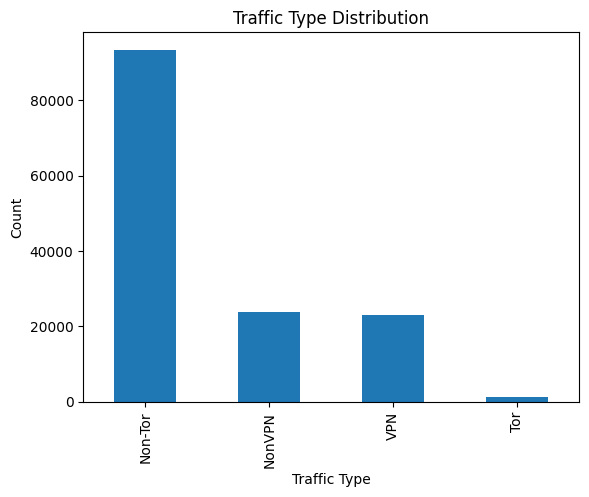

In [11]:
import matplotlib.pyplot as plt

df['Label'].value_counts().plot(kind='bar')

plt.title('Traffic Type Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

plt.show()

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Drop identifier columns
X = df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Label.1']).copy()

# Keep only numeric columns just in case
X = X.apply(pd.to_numeric, errors='coerce')

# Replace inf and -inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(0)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['Label'])

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred, target_names=le.classes_))

Accuracy: 0.983890341270402

Classification Report:

              precision    recall  f1-score   support

     Non-Tor       1.00      1.00      1.00     18671
      NonVPN       0.95      0.96      0.95      4773
         Tor       0.98      0.90      0.94       278
         VPN       0.96      0.95      0.96      4584

    accuracy                           0.98     28306
   macro avg       0.97      0.95      0.96     28306
weighted avg       0.98      0.98      0.98     28306



In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# 1. Build feature matrix again from cleaned df
X = df.drop(columns=['Flow ID', 'Src IP', 'Dst IP', 'Timestamp', 'Label', 'Label.1']).copy()

# 2. Force everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')

# 3. Replace inf values
X = X.replace([np.inf, -np.inf], np.nan)

# 4. Cap very large values just in case
X = X.clip(lower=-1e15, upper=1e15)

# 5. Fill missing values
X = X.fillna(0)

# 6. Final safety checks
print("Any NaN left:", X.isna().any().any())
print("Any +inf left:", np.isinf(X.to_numpy()).any())
print("Max value:", np.nanmax(X.to_numpy()))
print("Min value:", np.nanmin(X.to_numpy()))

# 7. Encode target
le = LabelEncoder()
y = le.fit_transform(df['Label'])

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 9. Train model
model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 10. Predict
pred = model.predict(X_test)

# 11. Results
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n")
print(classification_report(y_test, pred, target_names=le.classes_))

Any NaN left: False
Any +inf left: False
Max value: 1000000000000000.0
Min value: -2255.0
Accuracy: 0.979898254786971

Classification Report:

              precision    recall  f1-score   support

     Non-Tor       1.00      1.00      1.00     18671
      NonVPN       0.94      0.95      0.94      4773
         Tor       0.96      0.86      0.91       278
         VPN       0.95      0.95      0.95      4584

    accuracy                           0.98     28306
   macro avg       0.96      0.94      0.95     28306
weighted avg       0.98      0.98      0.98     28306



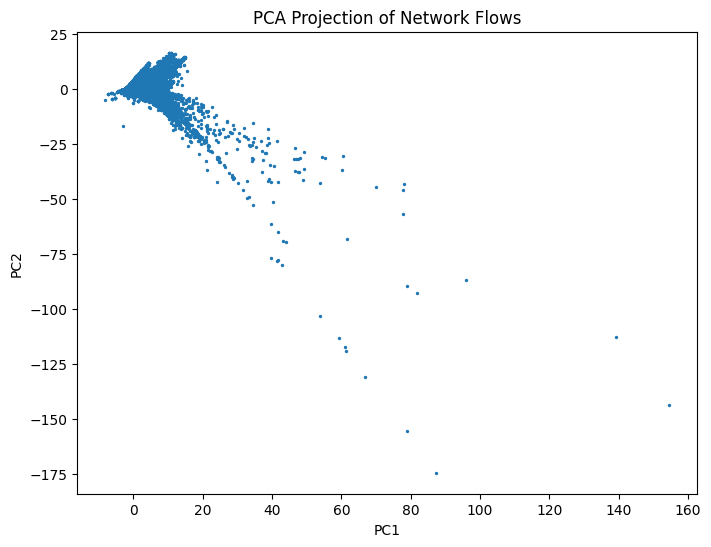

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=2)
plt.title("PCA Projection of Network Flows")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()